In [25]:
import numpy as np
import matplotlib.pyplot as pl
import json

with open("main_result.json") as f:
    result = json.load(f)

result["T_gas"], result["T_d"], result["Egas"], len(result["iterations"])

(41.959438942177485, 244.7263549880928, 8.689688612484974e-13, 101)

In [26]:
itrs = result["iterations"]
n = [itr["n"] for itr in itrs]
T_gas = [itr["T_gas"] for itr in itrs]
T_d = [itr["T_d"] for itr in itrs]
E_gas = [itr["Egas_guess"] for itr in itrs]
E_ir = [itr["EradVec_guess"][0] for itr in itrs]
E_opt = [itr["EradVec_guess"][1] for itr in itrs]
E_ion = [itr["EradVec_guess"][2] for itr in itrs]
Rvec_ir = [itr["Rvec"][0] for itr in itrs]
Rvec_opt = [itr["Rvec"][1] for itr in itrs]
Rvec_ion = [itr["Rvec"][2] for itr in itrs]
tau_ir = [itr["tau"][0] for itr in itrs]
tau_opt = [itr["tau"][1] for itr in itrs]
tau_ion = [itr["tau"][2] for itr in itrs]
delta_x = [itr["delta_x"] for itr in itrs]
delta_R_ir = [itr["delta_R"][0] for itr in itrs]
delta_R_opt = [itr["delta_R"][1] for itr in itrs]
delta_R_ion = [itr["delta_R"][2] for itr in itrs]
F0 = [itr["F0"] for itr in itrs]
F_ir = [itr["Fg"][0] for itr in itrs]
F_opt = [itr["Fg"][1] for itr in itrs]
F_ion = [itr["Fg"][2] for itr in itrs]
Fg_abs_sum = [itr["Fg_abs_sum"] for itr in itrs]
relax = [itr["relax"] for itr in itrs]

In [27]:
def plot_iteration_history(itrs, log_scale=None, ncols=4, figsize_per_axes=(4, 3)):
    """Grid-plot every scalar/per-group field of a SolverIterationState history against n.

    itrs: result["iterations"] -- a list of per-iteration dicts, as written by crash.jl's
          json_iteration_state. Vector fields (EradVec_guess, Rvec, tau, delta_R, Fg) are
          expanded into one series per group, named "<field>[<g>]".
    log_scale: optional dict {name: bool} overriding the default of True for every series
               except "relax". Names not present use the default. A series containing a
               non-positive value uses symlog instead of log when log-scaled, so negative
               or zero entries (e.g. Rvec, delta_R, F0, Fg) still show correctly.
    """
    log_scale = log_scale or {}
    n = [itr["n"] for itr in itrs]

    series = {}
    for key in itrs[0]:
        if key == "n":
            continue
        val0 = itrs[0][key]
        if isinstance(val0, list):
            for g in range(len(val0)):
                series[f"{key}[{g}]"] = [itr[key][g] for itr in itrs]
        else:
            series[key] = [itr[key] for itr in itrs]

    names = list(series.keys())
    nplots = len(names)
    ncols = min(ncols, nplots)
    nrows = -(-nplots // ncols)  # ceil division

    fig, axes = pl.subplots(nrows, ncols, figsize=(figsize_per_axes[0] * ncols, figsize_per_axes[1] * nrows),
                             squeeze=False)

    for i, name in enumerate(names):
        ax = axes[i // ncols, i % ncols]
        y = series[name]
        ax.plot(n, y)
        ax.set_xlabel("n")
        ax.set_title(name)

        want_log = log_scale.get(name, name != "relax")
        if want_log:
            if any(v <= 0 for v in y):
                ax.set_yscale("symlog")
            else:
                ax.set_yscale("log")

    # hide unused axes in the last row
    for i in range(nplots, nrows * ncols):
        axes[i // ncols, i % ncols].axis("off")

    fig.tight_layout()
    return fig, axes

(<Figure size 1600x1800 with 24 Axes>,
 array([[<Axes: title={'center': 'T_gas'}, xlabel='n'>,
         <Axes: title={'center': 'T_d'}, xlabel='n'>,
         <Axes: title={'center': 'Egas_guess'}, xlabel='n'>,
         <Axes: title={'center': 'EradVec_guess[0]'}, xlabel='n'>],
        [<Axes: title={'center': 'EradVec_guess[1]'}, xlabel='n'>,
         <Axes: title={'center': 'EradVec_guess[2]'}, xlabel='n'>,
         <Axes: title={'center': 'Rvec[0]'}, xlabel='n'>,
         <Axes: title={'center': 'Rvec[1]'}, xlabel='n'>],
        [<Axes: title={'center': 'Rvec[2]'}, xlabel='n'>,
         <Axes: title={'center': 'tau[0]'}, xlabel='n'>,
         <Axes: title={'center': 'tau[1]'}, xlabel='n'>,
         <Axes: title={'center': 'tau[2]'}, xlabel='n'>],
        [<Axes: title={'center': 'delta_x'}, xlabel='n'>,
         <Axes: title={'center': 'delta_R[0]'}, xlabel='n'>,
         <Axes: title={'center': 'delta_R[1]'}, xlabel='n'>,
         <Axes: title={'center': 'delta_R[2]'}, xlabel='n'>],

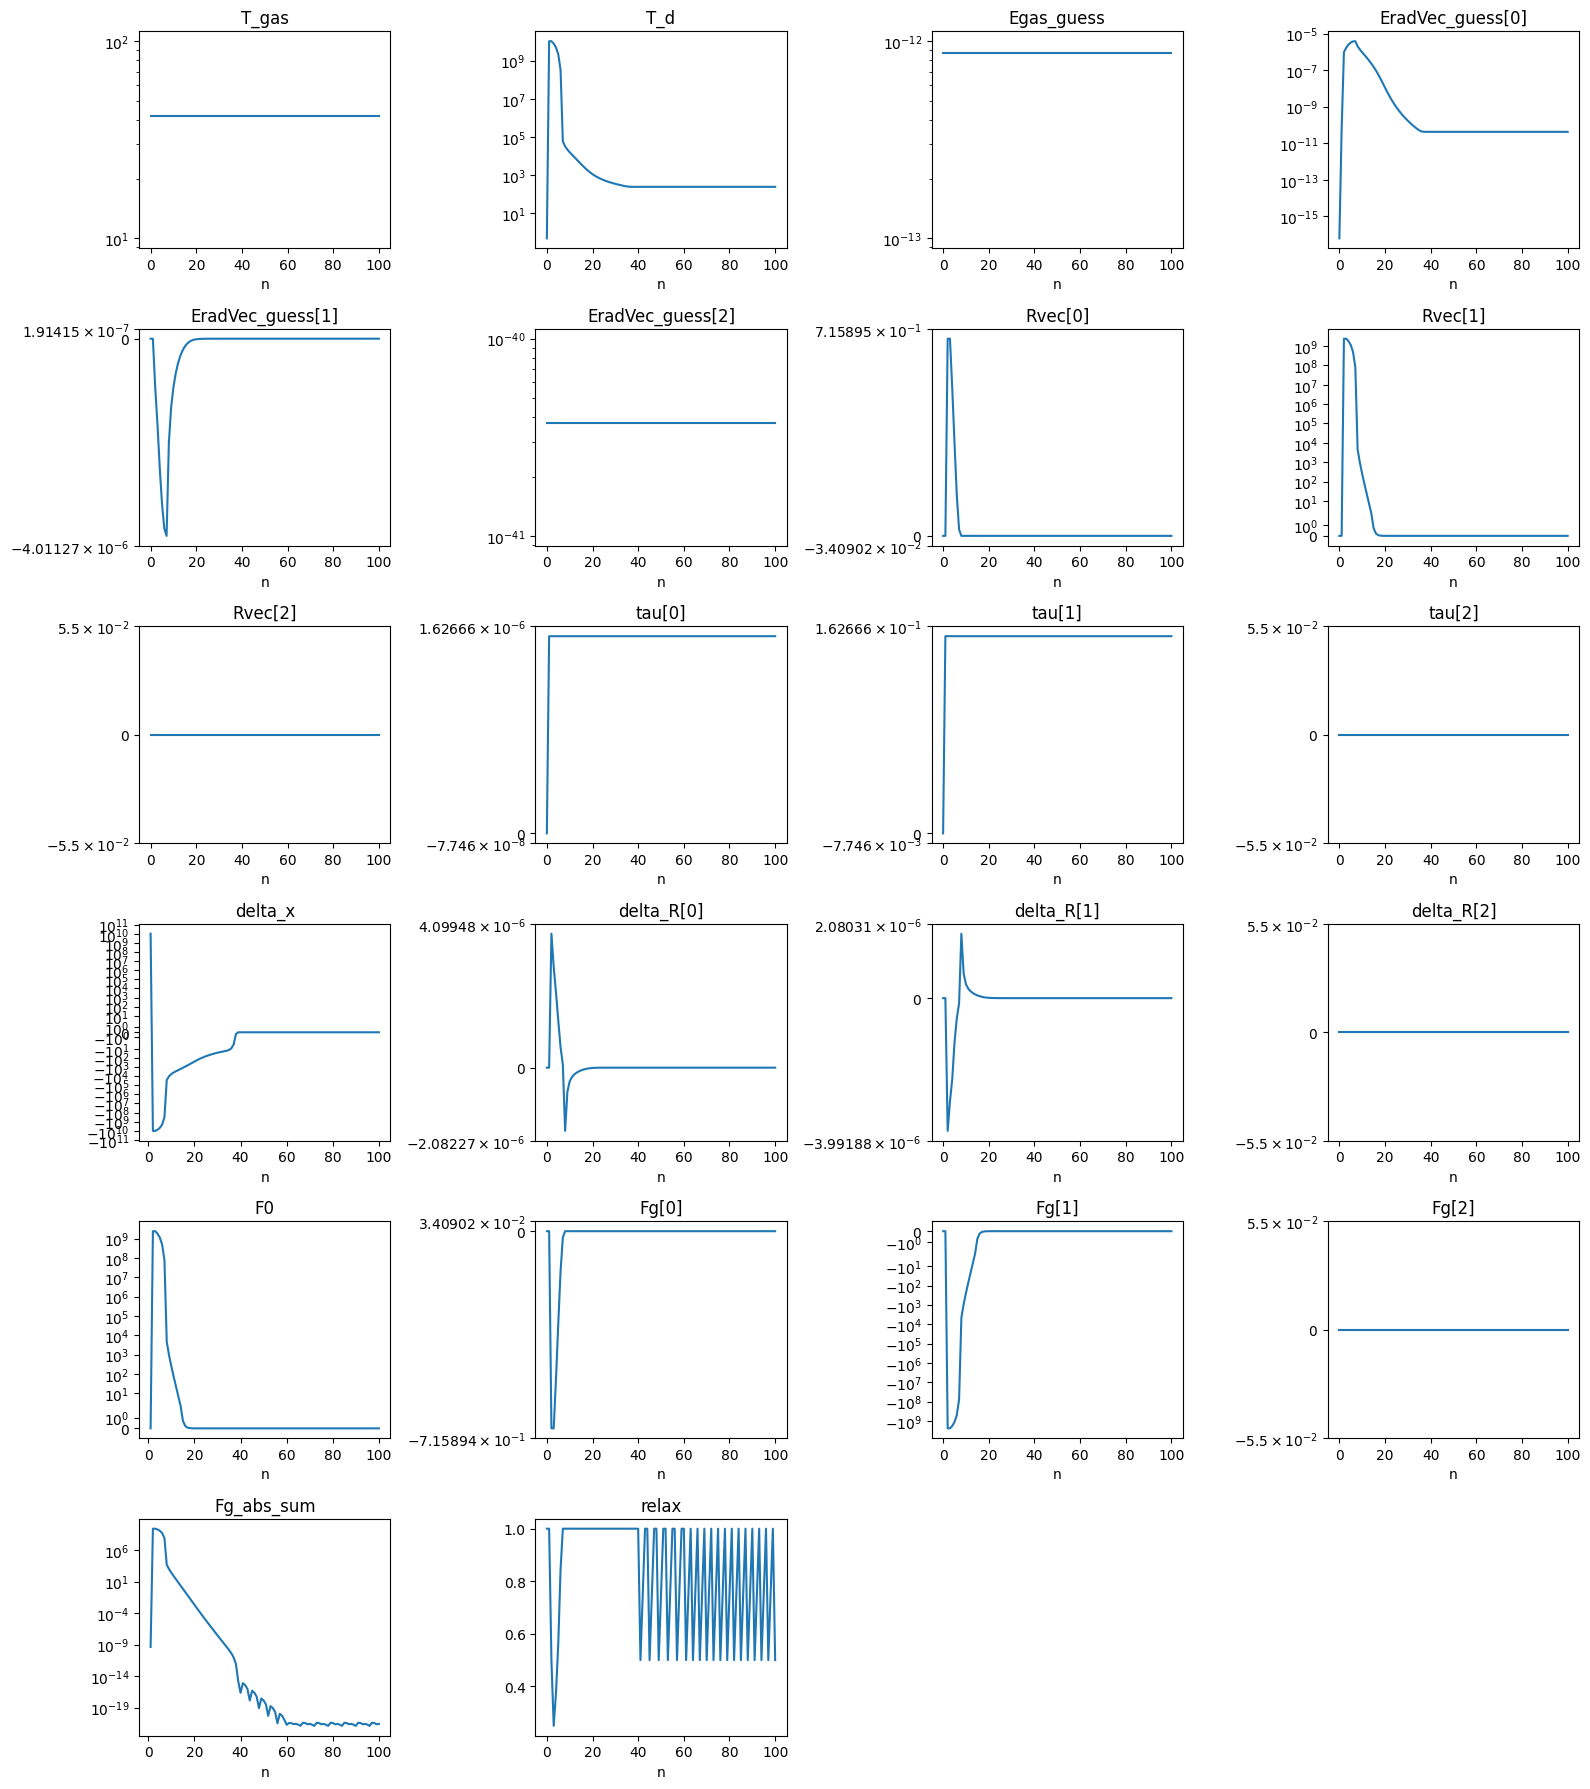

In [28]:
plot_iteration_history(result["iterations"])